# VIIRS Colombia: investigating the delivered outputs

**Part A: reproduce the client's concerns using only the delivered CSVs (no Earth Engine).**

The client raised two concerns:

1. **Negative values.** Some means (and minimums) are negative.
2. **A jump after 2016.** Values rise sharply from 2016 to 2017 and stay at the higher level.

How the data was produced (from `src/ee_viirs/1_zonal_stats_*.py`):

| Item | Value |
|---|---|
| 2016–2021 | `NOAA/VIIRS/DNB/ANNUAL_V21` |
| 2022–2024 | `NOAA/VIIRS/DNB/ANNUAL_V22` |
| Reducer | `mean`, `min`, `max`, `stdDev` per polygon, `reduceRegions(scale=480)` (native pixel 463.83 m) |
| Units | **municipio** (whole, MGN 2018), **cabecera** (urban centre, `clas_ccdgo = 1`), **rural** (municipio minus cabecera) |
| Bands | `average`, `average_masked`, `median`, `median_masked`, `minimum`, `maximum`, `cf_cvg`, `cvg` |

Background from the docs (see `viirs_docs/` and Elvidge et al. 2021):

* `average` is the cloud-free annual average radiance **including background noise**. Noise is centred on zero, so a dark pixel can be negative.
* `average_masked` is the same average with **background zeroed out**: a 3×3 data-range threshold indexed to cloud-free coverage, using a *multiyear* threshold grid. Only lit cells keep their value. The paper recommends masking because it *"eliminates background from being included in change analyses"*.
* V2.2 differs from V2.1: it mixes satellites (SNPP + NOAA-20 in 2022), accepts months with ≥1 cloud-free coverage (V2.1 needed ≥3), and treats grid cells with no median value differently.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "data" / "outputs"
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Palette: validated categorical slots 1-3 (safe for all-pairs comparison).
C = {"municipio": "#2a78d6", "cabecera": "#eb6834", "rural": "#1baf7a"}
MUTED, INK = "#8a8986", "#52514e"
BAND_STYLE = {"average": "-", "average_masked": "--"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
    "lines.linewidth": 2, "legend.frameon": False,
})


def mark_versions(ax, years_from=2016):
    # Shade the V2.2 period and label both versions.
    ax.axvspan(2021.5, 2024.5, color="#f1f0ec", zorder=0, lw=0)
    ax.axvline(2021.5, color=MUTED, lw=0.8, ls=":")
    ax.text(2021.4, 1.0, "V2.1", transform=ax.get_xaxis_transform(), ha="right", va="top", fontsize=8, color=MUTED)
    ax.text(2021.6, 1.0, "V2.2", transform=ax.get_xaxis_transform(), ha="left", va="top", fontsize=8, color=MUTED)

## 1. Load and harmonise the three tables

In [2]:
files = {
    "municipio": "mun_stats_clean_2.csv",
    "cabecera": "cabeceras_stats_clean_2.csv",
    "rural": "mun_nocabeceras_stats_clean_2.csv",
}
raw = {k: pd.read_csv(OUT / f) for k, f in files.items()}
for k, d in raw.items():
    print(f"{k:10s} {d.shape}  first cols: {list(d.columns[:4])}")

municipio  (6282, 35)  first cols: ['mpio_ccnct', 'shape_area', 'average_mean', 'average_min']
cabecera   (6282, 36)  first cols: ['clas_ccdgo', 'mpio_cdpmp', 'shape_area', 'average_mean']
rural      (6282, 34)  first cols: ['mpio_ccnct', 'average_mean', 'average_min', 'average_max']


**Provenance note.** `mun_stats_clean_2.csv` has camel-case columns (`average_stdDev`), but `2_data_cleaning.py` lower-cases every column and selects `*_stddev`. The municipio file therefore **was not produced by the current version of the cleaning script**. Values may still be fine, but we can't reproduce that file from the code as it stands. Column order also differs between files. We lower-case everything here.

In [3]:
frames = []
for unit, d in raw.items():
    d = d.copy()
    d.columns = d.columns.str.lower()
    id_col = "mpio_cdpmp" if unit == "cabecera" else "mpio_ccnct"
    d = d.rename(columns={id_col: "mpio"})
    d["unit"] = unit
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df["version"] = np.where(df["year"] <= 2021, "V2.1", "V2.2")
UNITS = ["municipio", "cabecera", "rural"]
YEARS = sorted(df["year"].unique())
df.groupby("unit").agg(rows=("mpio", "size"), municipios=("mpio", "nunique"),
                       year_min=("year", "min"), year_max=("year", "max"))

,rows,municipios,year_min,year_max
unit,,,,
cabecera,6282,698,2016,2024
municipio,6282,698,2016,2024
rural,6282,698,2016,2024


## 2. Integrity checks

In [4]:
sel = pd.read_csv(ROOT / "data" / "inputs" / "municipios_sel.csv")
sel_ids = set(sel["ID"])
checks = []
for unit in UNITS:
    d = df[df.unit == unit]
    ids = set(d.mpio)
    checks.append({
        "unit": unit,
        "duplicated (mpio, year)": int(d.duplicated(["mpio", "year"]).sum()),
        "rows per year (unique)": sorted(d.groupby("year").size().unique().tolist()),
        "ids in selection": len(ids & sel_ids),
        "ids NOT in selection": len(ids - sel_ids),
        "selected ids missing": len(sel_ids - ids),
        "NaN in average_mean": int(d["average_mean"].isna().sum()),
        "NaN in average_masked_mean": int(d["average_masked_mean"].isna().sum()),
    })
pd.DataFrame(checks).set_index("unit")

,"duplicated (mpio, year)",rows per year (unique),ids in selection,ids NOT in selection,selected ids missing,NaN in average_mean,NaN in average_masked_mean
unit,,,,,,,
municipio,0,[698],698,0,0,0,0
cabecera,0,[698],698,0,0,0,0
rural,0,[698],698,0,0,0,0


In [5]:
# Cabeceras are keyed by 2023 codes (mpio_cdpmp), the others by 2018 codes (mpio_ccnct).
# Do they line up one-to-one?
cab_ids = set(df.loc[df.unit == "cabecera", "mpio"])
mun_ids = set(df.loc[df.unit == "municipio", "mpio"])
print("cabecera ids also in municipio table:", len(cab_ids & mun_ids), "of", len(cab_ids))
print("only in cabecera:", sorted(cab_ids - mun_ids)[:20])
print("only in municipio:", sorted(mun_ids - cab_ids)[:20])

cabecera ids also in municipio table: 698 of 698
only in cabecera: []
only in municipio: []


## 3. Concern 1: negative values

We count negatives separately for every band × statistic × unit × year. A negative **mean** matters most to the client. A negative **min** only tells us that at least one pixel in the polygon is below zero.

In [6]:
neg_cols = ["average_mean", "average_min", "average_masked_mean", "average_masked_min",
            "median_mean", "median_masked_mean", "median_masked_min"]
neg = (df.assign(**{c: df[c] < 0 for c in neg_cols})
         .groupby(["unit", "year"])[neg_cols].sum().astype(int))
neg_t = neg.reset_index().melt(id_vars=["unit", "year"], var_name="column", value_name="n_negative")
neg_t.pivot_table(index=["unit", "column"], columns="year", values="n_negative").astype(int)

year                           2016  2017  2018  2019  2020  2021  2022  2023  2024
unit      column                                                                   
cabecera  average_masked_mean     0     0     0     0     0     0     0     0     0
          average_masked_min      0     0     0     0     0     5     0     0     0
          average_mean            0     0     0     0     0     1     0     0     0
          average_min             3     0     0     0     0     6     0     0     0
          median_masked_mean      0     0     0     0     0     0     0     0     0
          median_masked_min       0     0     0     0     0     5     0     0     0
          median_mean             1     0     0     0     0     1     0     0     0
municipio average_masked_mean     0     0     0     0     0     0     0     0     0
          average_masked_min     73     1     0     0     0    35     0     0    11
          average_mean           24     0     1     0     0     1     0     0     0
          average_min           552    28    39    79    47   133     4     3    36
          median_masked_mean      0     0     0     0     0     0     0     0     0
          median_masked_min     124     1     0     0     0    35     0     0    11
          median_mean            38     0     1     0     0     1     0     0     0
rural     average_masked_mean     0     0     0     0     0     0     0     0     0
          average_masked_min     73     1     0     0     0    34     0     0    11
          average_mean           32     0     1     0     0     1     0     0     0
          average_min           552    28    39    79    47   132     4     3    36
          median_masked_mean      0     0     0     0     0     1     0     0     0
          median_masked_min     124     1     0     0     0    34     0     0    11
          median_mean            47     0     1     0     0     2     0     0     0

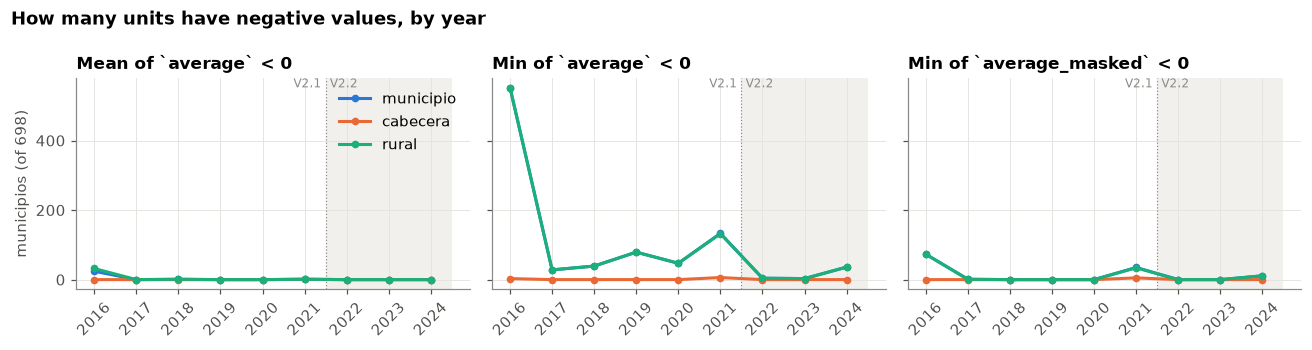

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, col, title in zip(axes, ["average_mean", "average_min", "average_masked_min"],
                          ["Mean of `average` < 0", "Min of `average` < 0", "Min of `average_masked` < 0"]):
    for unit in UNITS:
        s = neg.loc[unit, col]
        ax.plot(s.index, s.values, marker="o", ms=4, color=C[unit], label=unit)
    mark_versions(ax)
    ax.set_title(title)
    ax.set_xticks(YEARS)
    ax.tick_params(axis="x", labelrotation=45)
axes[0].set_ylabel("municipios (of 698)")
axes[0].legend(loc="upper right")
fig.suptitle("How many units have negative values, by year", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "a3_negatives_by_year.png")

In [8]:
# Which units have a negative mean, and what do they look like?
neg_rows = df[df.average_mean < 0][["unit", "mpio", "year", "average_mean", "average_min", "average_max",
                                    "average_masked_mean", "cf_cvg_mean"]]
print(len(neg_rows), "unit-years with negative average_mean")
neg_rows.sort_values(["year", "unit", "average_mean"]).head(40)

61 unit-years with negative average_mean


,unit,mpio,year,average_mean,average_min,average_max,average_masked_mean,cf_cvg_mean
48,municipio,5483,2016,-0.029975,-0.236619,3.291253,0.016709,24.321349
371,municipio,27006,2016,-0.020178,-0.110671,2.079313,0.003999,56.478610
553,municipio,68217,2016,-0.019007,-0.098451,1.103073,0.003474,58.311534
152,municipio,15183,2016,-0.017185,-0.094165,5.313501,0.009728,68.004806
670,municipio,85125,2016,-0.015916,-0.113875,17.340492,0.009749,61.092470
693,municipio,95025,2016,-0.015211,-0.113694,6.761560,0.000798,49.513374
372,municipio,27025,2016,-0.010524,-0.133369,0.372845,0.000000,36.633579
374,municipio,27135,2016,-0.010105,-1.500000,1.010479,0.005496,25.511534
692,municipio,95001,2016,-0.008266,-0.124793,26.044725,0.006670,49.684134
389,municipio,41206,2016,-0.007714,-0.097709,3.906862,0.002386,48.669335


In [9]:
# `average_masked` should be >= 0 (background is zeroed). Any negative masked pixel is unexpected.
m = df[df.average_masked_min < 0]
print(len(m), "unit-years with a negative pixel in average_masked")
print("most negative masked pixel:", m.average_masked_min.min())
m.groupby(["unit", "year"]).agg(n=("mpio", "size"), worst=("average_masked_min", "min")).unstack("unit")

244 unit-years with a negative pixel in average_masked
most negative masked pixel: -1.5


n                    worst                
unit cabecera municipio rural cabecera municipio rural
year                                                  
2016      NaN      73.0  73.0      NaN      -1.5  -1.5
2017      NaN       1.0   1.0      NaN      -1.5  -1.5
2021      5.0      35.0  34.0     -1.5      -1.5  -1.5
2024      NaN      11.0  11.0      NaN      -1.5  -1.5

In [10]:
# Split negative minimums into the exact -1.5 placeholder vs genuine small negatives (municipio table).
mu = df[df.unit == "municipio"]
pd.DataFrame({
    "average_min == -1.5": mu.average_min.eq(-1.5),
    "average_min < 0 (other)": mu.average_min.lt(0) & mu.average_min.ne(-1.5),
    "average_masked_min == -1.5": mu.average_masked_min.eq(-1.5),
    "average_masked_min < 0 (other)": mu.average_masked_min.lt(0) & mu.average_masked_min.ne(-1.5),
    "cf_cvg_min == 0": mu.cf_cvg_min.eq(0),
    "year": mu.year,
}).groupby("year").sum().T

year,2016,2017,2018,2019,2020,2021,2022,2023,2024
average_min == -1.5,26,18,32,34,28,120,4,0,35
average_min < 0 (other),526,10,7,45,19,13,0,3,1
average_masked_min == -1.5,2,1,0,0,0,35,0,0,11
average_masked_min < 0 (other),71,0,0,0,0,0,0,0,0
cf_cvg_min == 0,2,3,10,7,0,9,4,0,35


## 4. Concern 2: the 2016 → 2017 jump

For each unit type we plot the median across the 698 municipios, with the interquartile range shaded. Solid lines are unmasked `average`; dashed lines are `average_masked`.

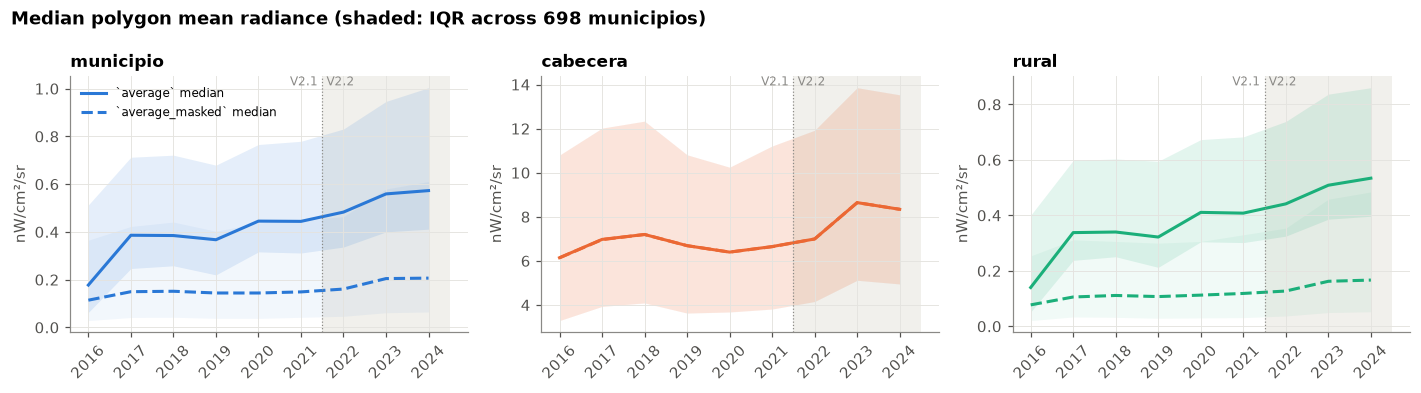

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, unit in zip(axes, UNITS):
    d = df[df.unit == unit]
    for band, ls in BAND_STYLE.items():
        q = d.groupby("year")[f"{band}_mean"].quantile([0.25, 0.5, 0.75]).unstack()
        ax.plot(q.index, q[0.5], ls=ls, color=C[unit], label=f"`{band}` median")
        ax.fill_between(q.index, q[0.25], q[0.75], color=C[unit], alpha=0.12 if band == "average" else 0.06, lw=0)
    mark_versions(ax)
    ax.set_title(unit)
    ax.set_xticks(YEARS)
    ax.tick_params(axis="x", labelrotation=45)
    ax.set_ylabel("nW/cm²/sr")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Median polygon mean radiance (shaded: IQR across 698 municipios)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "a4_timeseries_median_iqr.png")

In [12]:
summary = (df.groupby(["unit", "year"])[["average_mean", "average_masked_mean"]].median()
             .unstack("unit").round(3))
summary

average_mean                  average_masked_mean                 
unit     cabecera municipio  rural            cabecera municipio  rural
year                                                                   
2016        6.143     0.177  0.140               6.138     0.114  0.077
2017        6.974     0.386  0.338               6.964     0.150  0.106
2018        7.197     0.385  0.340               7.197     0.151  0.111
2019        6.690     0.367  0.322               6.690     0.144  0.107
2020        6.398     0.445  0.411               6.398     0.144  0.112
2021        6.650     0.444  0.408               6.643     0.149  0.118
2022        6.994     0.483  0.441               6.994     0.161  0.127
2023        8.642     0.559  0.509               8.642     0.205  0.162
2024        8.340     0.573  0.534               8.340     0.206  0.167

### 4.1 Year-over-year change per municipio

If 2016 is a genuine year, the 2016→17 change should look like the other year pairs. If it's an artefact, it will stand out. The version switch (2021→22) is the second transition to check.

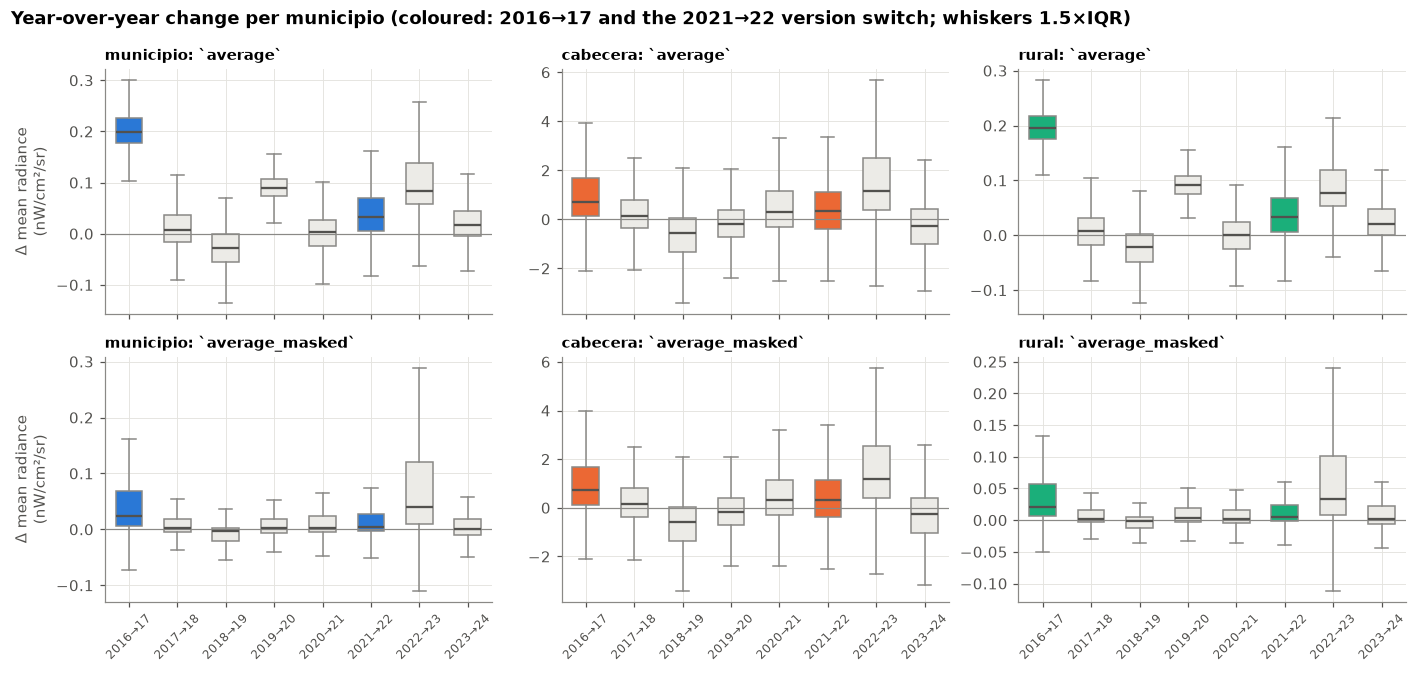

In [13]:
def yoy(unit, col):
    w = df[df.unit == unit].pivot(index="mpio", columns="year", values=col)
    return pd.DataFrame({f"{a}→{str(b)[2:]}": w[b] - w[a] for a, b in zip(YEARS[:-1], YEARS[1:])})

fig, axes = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True)
for j, unit in enumerate(UNITS):
    for i, band in enumerate(BAND_STYLE):
        ax = axes[i, j]
        y = yoy(unit, f"{band}_mean")
        bp = ax.boxplot(y.values, showfliers=False, widths=0.55, patch_artist=True,
                        medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED),
                        capprops=dict(color=MUTED), boxprops=dict(edgecolor=MUTED))
        for k, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(C[unit] if k in (0, 5) else "#ecebe7")
        ax.axhline(0, color=MUTED, lw=0.8)
        ax.set_xticks(range(1, len(y.columns) + 1), y.columns, rotation=45, fontsize=8)
        ax.set_title(f"{unit}: `{band}`", fontsize=10)
axes[0, 0].set_ylabel("Δ mean radiance\n(nW/cm²/sr)")
axes[1, 0].set_ylabel("Δ mean radiance\n(nW/cm²/sr)")
fig.suptitle("Year-over-year change per municipio (coloured: 2016→17 and the 2021→22 version switch; whiskers 1.5×IQR)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "a4_yoy_boxplots.png")

In [14]:
rows = []
for unit in UNITS:
    for band in BAND_STYLE:
        y = yoy(unit, f"{band}_mean")
        rows.append({"unit": unit, "band": band,
                     **{c: f"{y[c].median():+.3f} ({(y[c] > 0).mean():.0%}↑)" for c in y.columns}})
pd.DataFrame(rows).set_index(["unit", "band"])

2016→17        2017→18        2018→19        2019→20        2020→21        2021→22        2022→23        2023→24
unit      band                                                                                                                                  
municipio average         +0.199 (99%↑)  +0.008 (59%↑)  -0.027 (24%↑)  +0.089 (95%↑)  +0.003 (53%↑)  +0.033 (80%↑)  +0.083 (98%↑)  +0.017 (71%↑)
          average_masked  +0.024 (92%↑)  +0.002 (61%↑)  -0.004 (33%↑)  +0.002 (60%↑)  +0.003 (62%↑)  +0.005 (66%↑)  +0.039 (93%↑)  +0.000 (52%↑)
cabecera  average         +0.725 (79%↑)  +0.144 (58%↑)  -0.548 (27%↑)  -0.177 (41%↑)  +0.317 (63%↑)  +0.324 (63%↑)  +1.152 (84%↑)  -0.265 (38%↑)
          average_masked  +0.727 (78%↑)  +0.144 (58%↑)  -0.567 (27%↑)  -0.179 (40%↑)  +0.318 (63%↑)  +0.309 (62%↑)  +1.177 (84%↑)  -0.265 (38%↑)
rural     average         +0.195 (99%↑)  +0.008 (58%↑)  -0.021 (28%↑)  +0.091 (97%↑)  -0.000 (49%↑)  +0.033 (81%↑)  +0.078 (98%↑)  +0.021 (76%↑)
          average_masked  +0.020 (94%↑)  +0.002 (62%↑)  -0.002 (38%↑)  +0.003 (66%↑)  +0.002 (61%↑)  +0.005 (67%↑)  +0.033 (94%↑)  +0.002 (58%↑)

### 4.2 Is the jump an additive offset (background) or a multiplicative change (lights)?

* If the whole scene's noise floor was lower in 2016, every polygon shifts by roughly **the same absolute amount**, and the shift shows up in the **unmasked** band only. Masked background is 0 anyway.
* If lights really got brighter (or the sensor gain changed), the change **scales with brightness** and shows up in the **masked** band too.

Two diagnostics:

1. **Background contribution** = `average_mean − average_masked_mean`. This is what the background pixels add to the polygon mean.
2. **Noise-floor proxy** = the polygon's `average_min`. In dark, rural polygons this is essentially the darkest background pixel.

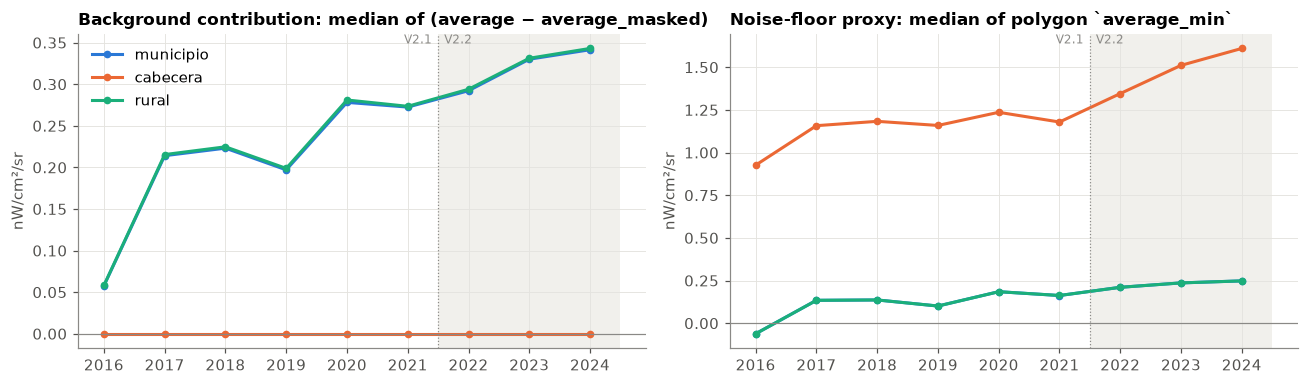

In [15]:
df["background_contrib"] = df["average_mean"] - df["average_masked_mean"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for unit in UNITS:
    s = df[df.unit == unit].groupby("year")["background_contrib"].median()
    axes[0].plot(s.index, s.values, marker="o", ms=4, color=C[unit], label=unit)
    s = df[df.unit == unit].groupby("year")["average_min"].median()
    axes[1].plot(s.index, s.values, marker="o", ms=4, color=C[unit], label=unit)
axes[0].set_title("Background contribution: median of (average − average_masked)")
axes[1].set_title("Noise-floor proxy: median of polygon `average_min`")
for ax in axes:
    mark_versions(ax)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_xticks(YEARS)
    ax.set_ylabel("nW/cm²/sr")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "a4_background_offset.png")

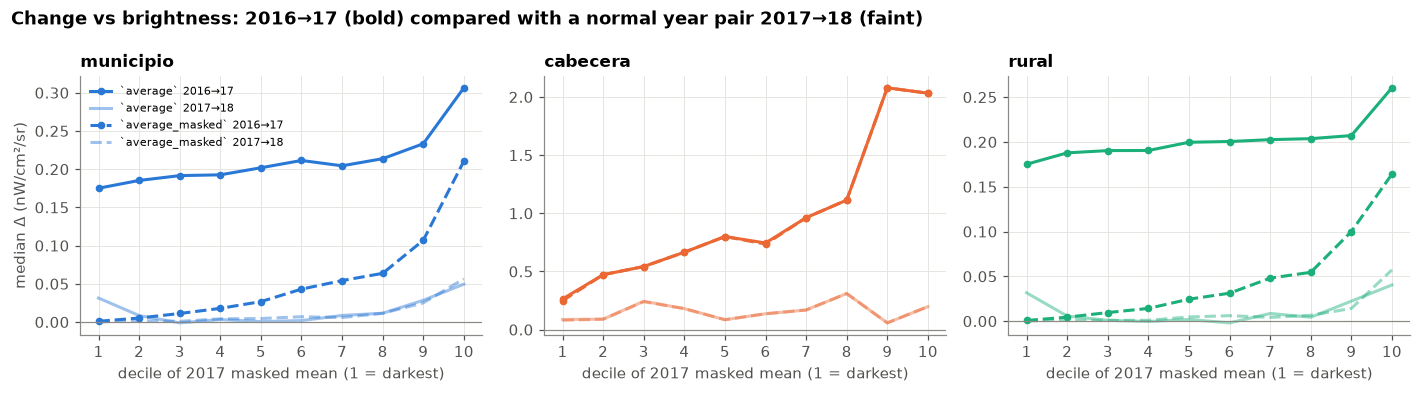

In [16]:
# Change 2016→17 as a function of how lit a municipio is (deciles of 2017 masked mean).
# Offset hypothesis: the unmasked change is flat across deciles. Gain hypothesis: it grows with brightness.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)
for ax, unit in zip(axes, UNITS):
    w_a = df[df.unit == unit].pivot(index="mpio", columns="year", values="average_mean")
    w_m = df[df.unit == unit].pivot(index="mpio", columns="year", values="average_masked_mean")
    dec = pd.qcut(w_m[2017].rank(method="first"), 10, labels=range(1, 11))
    for w, band in [(w_a, "average"), (w_m, "average_masked")]:
        for (a, b), alpha in [((2016, 2017), 1.0), ((2017, 2018), 0.45)]:
            s = (w[b] - w[a]).groupby(dec, observed=True).median()
            ax.plot(s.index.astype(int), s.values, ls=BAND_STYLE[band], color=C[unit], alpha=alpha,
                    marker="o" if a == 2016 else None, ms=4, label=f"`{band}` {a}→{str(b)[2:]}")
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_title(unit)
    ax.set_xlabel("decile of 2017 masked mean (1 = darkest)")
    ax.set_xticks(range(1, 11))
axes[0].set_ylabel("median Δ (nW/cm²/sr)")
axes[0].legend(fontsize=7)
fig.suptitle("Change vs brightness: 2016→17 (bold) compared with a normal year pair 2017→18 (faint)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "a4_change_by_brightness.png")

## 5. Observation quality and the version switch

`cf_cvg` counts cloud-free observations per pixel; `cvg` counts all observations free of sunlight and moonlight. Colombia is cloudy, so fewer cloud-free observations mean a noisier average and a higher masking threshold. V2.2 in 2022 adds NOAA-20 months, which should push `cvg` up.

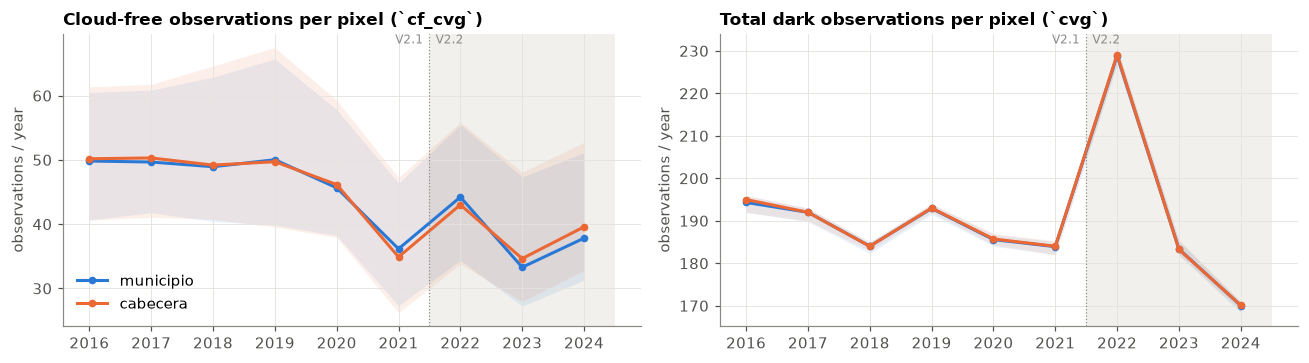

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for ax, col, title in zip(axes, ["cf_cvg_mean", "cvg_mean"],
                          ["Cloud-free observations per pixel (`cf_cvg`)", "Total dark observations per pixel (`cvg`)"]):
    for unit in ["municipio", "cabecera"]:
        q = df[df.unit == unit].groupby("year")[col].quantile([0.25, 0.5, 0.75]).unstack()
        ax.plot(q.index, q[0.5], color=C[unit], marker="o", ms=4, label=unit)
        ax.fill_between(q.index, q[0.25], q[0.75], color=C[unit], alpha=0.1, lw=0)
    mark_versions(ax)
    ax.set_title(title)
    ax.set_xticks(YEARS)
    ax.set_ylabel("observations / year")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "a5_coverage.png")

In [18]:
# Does low cloud-free coverage explain negatives or noise? Correlate per year for rural areas.
r = df[df.unit == "rural"]
pd.DataFrame({
    "corr(cf_cvg_mean, average_min)": r.groupby("year").apply(lambda g: g.cf_cvg_mean.corr(g.average_min)),
    "corr(cf_cvg_mean, background_contrib)": r.groupby("year").apply(lambda g: g.cf_cvg_mean.corr(g.background_contrib)),
    "median cf_cvg": r.groupby("year").cf_cvg_mean.median(),
}).round(3)

,"corr(cf_cvg_mean, average_min)","corr(cf_cvg_mean, background_contrib)",median cf_cvg
year,,,
2016,0.216,-0.085,49.824
2017,0.116,-0.301,49.670
2018,0.095,-0.238,48.964
2019,0.186,-0.185,50.025
2020,0.280,-0.330,45.653
2021,0.444,-0.217,36.166
2022,0.083,-0.440,44.232
2023,0.173,-0.305,33.254
2024,0.276,-0.276,37.842


## 6. Consistency: do cabecera + rural add back up to municipio?

Area-weighted: `mun ≈ (A_cab·cab + A_rural·rural) / (A_cab + A_rural)`. The polygons were built separately (simplified, and small slivers under 60,000 m² dropped from rural), and pixel-based means aren't exactly area-weighted. So we expect agreement within a few percent, not exact equality. Large systematic gaps would point to an extraction or geometry problem.

In [19]:
areas = pd.read_csv(OUT / "areaskm2_municipios.csv")[["mpio_ccnct", "areakm2_cab", "areakm2_mun", "areakm2_munNoCab"]]
areas = areas.rename(columns={"mpio_ccnct": "mpio"})
print("area rows:", len(areas), "| cab+rural vs mun area, median ratio:",
      round(((areas.areakm2_cab + areas.areakm2_munNoCab) / areas.areakm2_mun).median(), 4))

band = "average_masked_mean"
w = df.pivot_table(index=["mpio", "year"], columns="unit", values=band).reset_index().merge(areas, on="mpio", how="left")
w["recomposed"] = (w.areakm2_cab * w.cabecera + w.areakm2_munNoCab * w.rural) / (w.areakm2_cab + w.areakm2_munNoCab)
w["rel_err"] = (w.recomposed - w.municipio) / w.municipio
print("missing areas:", w.areakm2_cab.isna().sum())
w.groupby("year")["rel_err"].describe(percentiles=[0.05, 0.5, 0.95]).round(3)

area rows: 698 | cab+rural vs mun area, median ratio: 1.0
missing areas: 0


,count,mean,std,min,5%,50%,95%,max
year,,,,,,,,
2016,689.0,0.001,0.011,-0.009,-0.002,0.0,0.003,0.251
2017,693.0,0.001,0.010,-0.007,-0.002,0.0,0.002,0.222
2018,694.0,0.045,1.171,-0.007,-0.002,0.0,0.002,30.857
2019,690.0,0.001,0.008,-0.007,-0.002,0.0,0.002,0.174
2020,694.0,0.001,0.013,-0.007,-0.002,0.0,0.002,0.280
2021,696.0,0.001,0.007,-0.007,-0.002,-0.0,0.002,0.156
2022,693.0,0.001,0.008,-0.006,-0.002,-0.0,0.002,0.144
2023,695.0,0.001,0.007,-0.006,-0.001,-0.0,0.002,0.131
2024,693.0,0.001,0.007,-0.005,-0.001,0.0,0.002,0.140


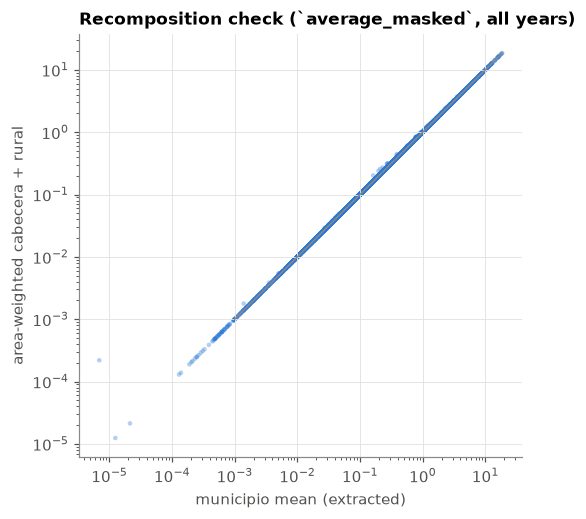

In [20]:
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(w.municipio, w.recomposed, s=9, alpha=0.35, color=C["municipio"], edgecolor="none")
lim = [max(1e-3, w[["municipio", "recomposed"]].min().min()), w[["municipio", "recomposed"]].max().max()]
ax.plot(lim, lim, color=MUTED, lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("municipio mean (extracted)")
ax.set_ylabel("area-weighted cabecera + rural")
ax.set_title("Recomposition check (`average_masked`, all years)")
fig.savefig(FIG / "a6_recomposition.png")

The rare large relative errors happen where the municipio masked mean is ≈ 0, so the ratio blows up. For 5–95 % of cases the recomposition matches within ±0.3 %. **The three tables are consistent with each other; no sign of an extraction or geometry mix-up.**

## 7. Findings so far (Part A)

### F1. Negative values come from the *unmasked* background plus a `-1.5` no-data placeholder
* **No `average_masked_mean` is ever negative.** All 61 negative means are in the unmasked `average` / `median` bands.
* 56 of those 61 are in **2016**, in municipios with almost no lights. Their negative means are tiny (−0.03 to 0 nW/cm²/sr).
* Background pixels in the unmasked band are noise around a baseline. In 2016 that baseline sits below zero for most of the country (median rural `average_min` −0.06), so a dark municipio can average out negative.
* **A value of exactly `-1.5` appears as a pixel minimum in every year** (see the table below): up to 120 municipios in the unmasked band and up to 35 in the masked band (2021). The V2.x readme uses `-1.5` as a placeholder median for grid cells lacking cloud-free coverage (item 3). Earth Engine does not mask it, so it enters our means and minimums as a real radiance. At polygon level it only partly coincides with `cf_cvg_min == 0` (24 %), so the exact pixel rule has to be verified in GEE (H1).
* **2016 only:** 71 municipios have *lit* (masked-in) pixels with small negative averages (−0.001 to −0.06). The 2016 baseline shift therefore reaches into lit pixels, not just the background.

### F2. The 2016→17 jump has two parts
1. **An additive offset in the unmasked band (the dominant part).** Unmasked means rise by about +0.18–0.21 nW/cm²/sr in 99 % of municipios, **almost regardless of brightness** (flat across deciles). The change is carried entirely by background pixels: the background contribution (`average − average_masked`) goes 0.06 → 0.21. This is not new lighting. The noise floor of the unmasked product moves between years. Smaller offsets of the same kind appear in 2019→20 (+0.09) and 2022→23 (+0.08), and the background contribution drifts upward over time (0.06 → 0.34).
2. **A smaller rise in the masked band that grows with brightness.** Masked means rise +0.02 in dark municipios and up to +0.2 in bright ones. This is *partly* the same offset: a ~+0.2 shift applied only to lit pixels raises the polygon mean by 0.2 × (lit fraction), and brighter municipios have larger lit fractions. It cannot be the whole story for cabeceras (nearly fully lit), which rise +0.73 nW/cm²/sr (~12 %) in 78 % of cases, well above the offset. The excess behaves like a gain change or real new lighting. 2022→23 shows a similar, larger pattern. Part A can't separate real from artefact; Part B will run the same test outside Colombia and for 2013–2015.

### F3. Version switch 2021→22
The V2.1→V2.2 transition is **not** the main discontinuity. Its median change is within the normal range of year-to-year variation in both bands. Two caveats: `cvg` jumps (184 → 229, because NOAA-20 months were added), and the masking threshold grids differ between versions. The one sizeable step is 2022→23, which falls inside V2.2.

### F4. Integrity
698 municipios × 9 years in all three tables, no duplicates, no NaN, and cabecera/municipio codes match one-to-one. Cabecera + rural recompose the municipio value. One provenance issue: `mun_stats_clean_2.csv` wasn't produced by the current `2_data_cleaning.py` (camel-case columns).

### Recommendation (provisional)
Use **`average_masked`** for all change analysis, and **exclude `-1.5` / `cf_cvg == 0` pixels** before reducing. The unmasked `average` carries a year-varying background offset larger than the real change in most rural areas. For rural municipios, the 2016→17 offset (+0.2) exceeds the entire 2017→2024 masked change (+0.06).

## 8. Hypotheses for Part B (Earth Engine)

| # | Hypothesis | Test | Needs polygons? |
|---|---|---|---|
| H1 | The `-1.5` values are a no-data placeholder, not radiance | Pixel check over Colombia: which bands and years contain `-1.5`, and how they relate to `cf_cvg` | No |
| H2 | The unmasked background offset is product-wide, not Colombian | Median `average` over unlit pixels (masked == 0, cf_cvg > 0) per year, 2013–2025, for Colombia, the Amazon, Sahara and Australia | No |
| H3 | The masked 2016→17 and 2022→23 rises are product-wide (gain/calibration), not local | Median masked radiance of stable, well-lit pixels per year in other countries | No |
| H4 | 2016 is anomalous relative to 2013–2015 as well | Extend H2/H3 back to 2013 | No |
| H5 | Removing `-1.5` pixels changes the published numbers materially | Re-extract with those pixels masked | **Yes** |
| H6 | `scale=480` vs native 463.83 m makes no material difference | Re-extract a sample at native scale | **Yes** |
| H7 | V2.1 and V2.2 are comparable across the 2021→22 seam | EOG may publish V2.2 for 2021 or earlier outside GEE. If not, compare stable pixels across the seam | No / partly |